In [10]:
import numpy as np    
import matplotlib.pyplot as plt

脉冲位置: [-1.25 -0.75 -0.25  0.25  0.75  1.25]


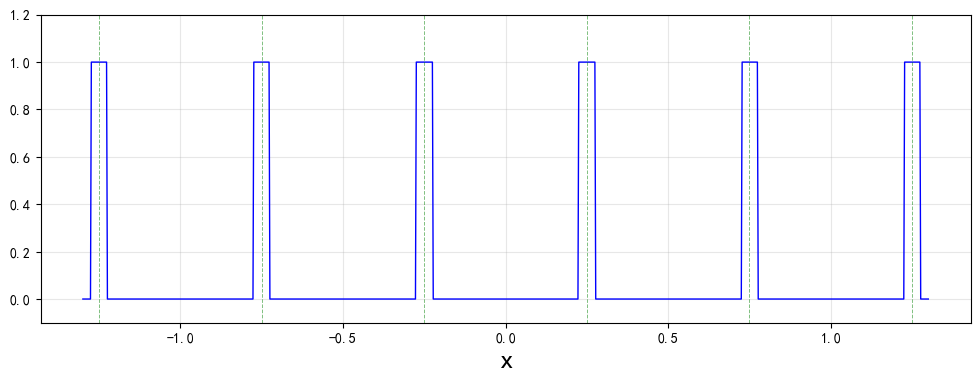

In [45]:
import numpy as np
import matplotlib.pyplot as plt

x_set = np.linspace(-1.3, 1.3, 1000)
fx = np.zeros_like(x_set)

# 正确的方法：将列表转换为NumPy数组然后乘以0.5
positions = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * 0.5
pulse_width = 0.05

print("脉冲位置:", positions)

# 为每个位置创建脉冲
for pos in positions:
    mask = (x_set > pos - pulse_width/2) & (x_set < pos + pulse_width/2)
    fx[mask] = 1

# 可视化
plt.figure(figsize=(12, 4))
plt.plot(x_set, fx, 'b-', linewidth=1)
plt.xlabel('x', fontsize=20) 
#plt.ylabel('f(x)')
#plt.title('狄拉克函数梳')
plt.grid(True, alpha=0.3)

for pos in positions:
    plt.axvline(x=pos, color='green', linestyle='--', alpha=0.5,linewidth=0.7)
    #plt.text(pos, 1.05, f'{pos}', ha='center', va='bottom', fontsize=10)

plt.ylim(-0.1, 1.2)
plt.show()

脉冲位置: [-1.25 -0.75 -0.25  0.25  0.75  1.25]


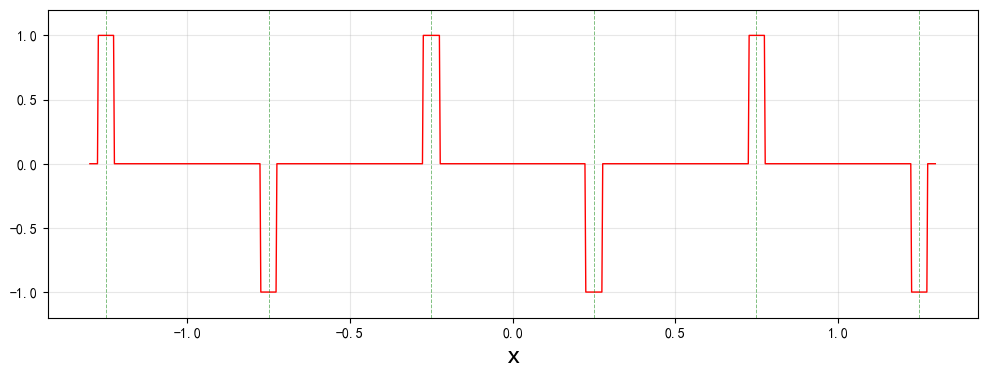

In [43]:
import numpy as np
import matplotlib.pyplot as plt

x_set = np.linspace(-1.3, 1.3, 1000)
fx = np.zeros_like(x_set)

# 定义位置
positions = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * 0.5
pulse_width = 0.05

print("脉冲位置:", positions)

# 为每个位置创建脉冲，某些位置为-1
for i, pos in enumerate(positions):
    mask = (x_set > pos - pulse_width/2) & (x_set < pos + pulse_width/2)
    if i in [1, 3, 5]:  # 第2、4、6个位置（索引1,3,5）对应 -1.5, 0.5, 2.5 的位置
        fx[mask] = -1
    else:
        fx[mask] = 1

# 可视化
plt.figure(figsize=(12, 4))
plt.plot(x_set, fx, color='red', linewidth=1)  # 修正：只用color参数
plt.xlabel('x', fontsize=20)  # 调大字体并用红色
plt.grid(True, alpha=0.3)

# 添加水平参考线
#plt.axhline(y=0, color='black', linewidth=0.8)

for pos in positions:
    plt.axvline(x=pos, color='green', linestyle='--', alpha=0.5,linewidth=0.7)
    #plt.text(pos, 1.2 if pos not in [positions[1], positions[3], positions[5]] else -1.2, 
            # f'{pos}', ha='center', va='bottom' if pos not in [positions[1], positions[3], positions[5]] else 'top', 
            # fontsize=10)

plt.ylim(-1.2, 1.2)
plt.show()

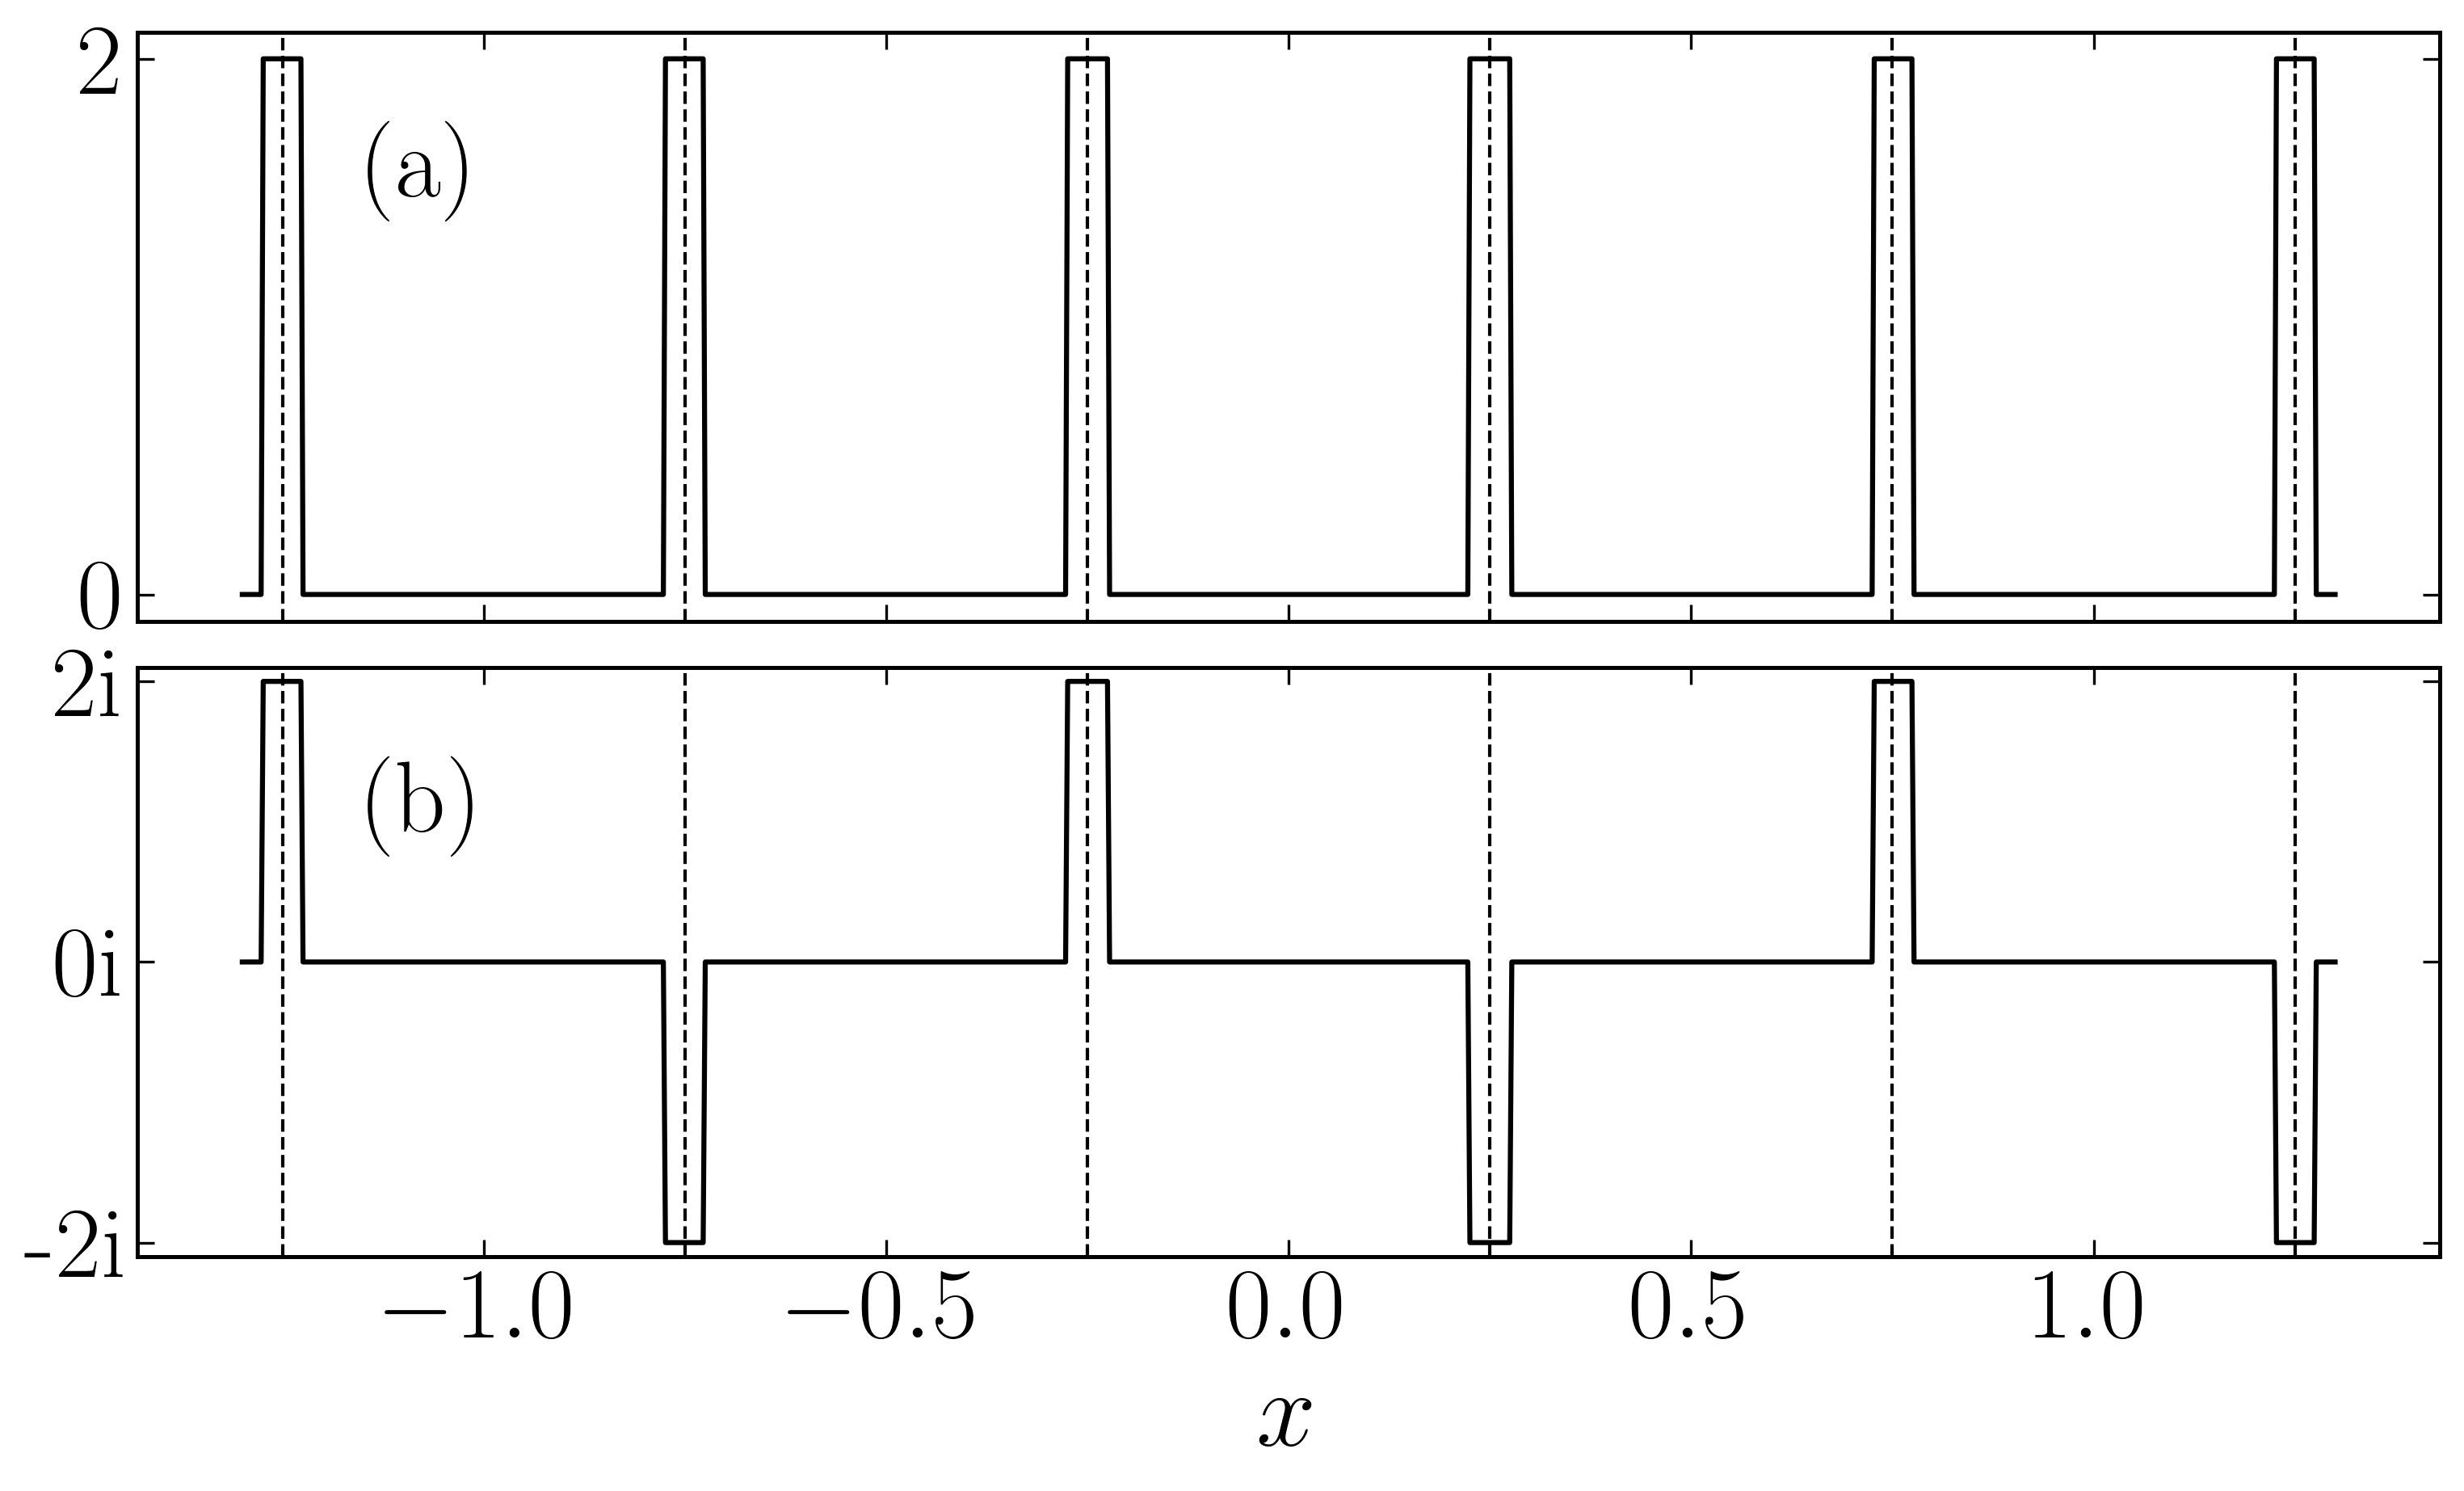

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.ticker as ticker
# 设置LaTeX字体样式
plt.rcParams.update({
    "text.usetex": True,  # 使用LaTeX渲染文本
    "font.family": "serif",  # 使用衬线字体
    "font.serif": ["Times New Roman"],  # Times New Roman是物理文献常用字体
    "font.size": 12,  # 基础字号
})

# 创建 2x1 的子图布局
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), dpi=300)

# 第一个子图：所有脉冲为1
x_set = np.linspace(-1.3, 1.3, 1000)
fx1 = np.zeros_like(x_set)
positions = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * 0.5
pulse_width = 0.05

# 为每个位置创建脉冲（所有为1）
for pos in positions:
    mask = (x_set > pos - pulse_width/2) & (x_set < pos + pulse_width/2)
    fx1[mask] = 2

# 第二个子图：部分脉冲为-1
fx2 = np.zeros_like(x_set)
for i, pos in enumerate(positions):
    mask = (x_set > pos - pulse_width/2) & (x_set < pos + pulse_width/2)
    if i in [1, 3, 5]:  # 第2、4、6个位置为-1
        fx2[mask] = -2
    else:
        fx2[mask] = 2

# 绘制第一个子图
ax1 = axes[0]
ax1.plot(x_set, fx1, 'k-', linewidth=1.5)
##ax1.set_ylabel(r'$f(x)$', fontsize=12)
#ax1.grid(True, alpha=0.3)
for pos in positions:
    ax1.axvline(x=pos, color='black', linestyle='--', alpha=1, linewidth=1)
ax1.set_ylim(-0.1, 2.1)
ax1.text(0.1, 0.85, r"$\mathrm{(a)}$", transform=ax1.transAxes,
        fontsize=30, va='top', ha='left')
ax1.set_xticklabels([])

def y_tick_formatter(val, pos):
    return f"{val:.0f}i"

# 绘制第二个子图
ax2 = axes[1]
ax2.plot(x_set, fx2, color='black', linewidth=1.5)
ax2.set_xlabel(r'$x$', fontsize=32)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(y_tick_formatter))
#ax2.set_ylabel(r'$f(x)$', fontsize=12)
#ax2.grid(True, alpha=0.3)
for pos in positions:
    ax2.axvline(x=pos, color='black', linestyle='--', alpha=1, linewidth=1)
ax2.set_ylim(-2.1, 2.1)
ax2.text(0.1, 0.85, r"$\mathrm{(b)}$", transform=ax2.transAxes,
        fontsize=30, va='top', ha='left')

# 为两个子图设置相同的刻度样式
for ax in axes:
    ax.tick_params(
        axis='both', which='major', direction='in',
        length=5, width=0.8, labelsize=30,
        top=True, right=True  # 开启上和右边的刻度线
    )
    ax.tick_params(
        axis='both', which='minor', direction='in',
        length=3, width=0.5,
        top=True, right=True
    )
    # 设置边框线宽
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# 调整子图间距
plt.tight_layout(pad=0.1, w_pad=1.0, h_pad=-0.2)

# 保存图像
shidong = 1
if shidong == 1:
    save_folder = r"C:\Users\taoji\Desktop\论文写作\wenwu\yiweiPTduichen\wenben\11"
    os.makedirs(save_folder, exist_ok=True)
    
    # EPS格式（矢量图）
    eps_path = os.path.join(save_folder, "fig05.eps")
    plt.savefig(eps_path, format='eps', bbox_inches='tight', dpi=300)
    
    # PNG格式（适合预览）
    png_path = os.path.join(save_folder, "fig05.png")
    plt.savefig(png_path, format='png', bbox_inches='tight', dpi=300)

plt.show()